## This notebook shows how to run the sampler and post-process the chain.

In [2]:
import numpy as np, matplotlib.pyplot as plt
import mhealpy as mhp
import pickle
from resolve import sampler

### The four required inputs to the sampler are rho, C, psrs_theta, and psrs_phi.
### You can use Defiant to get rho and C.

In [ ]:
rhok = # the PFOS cross-correlations (Npairs,)
Ck = # the PFOS pair-covariance matrix (Npairs, Npairs)
Sk = # the PFOS amplitude
rho = rhok / Sk # scale the cross-correlations
C = Ck / Sk**2 # scale the covariance matrix
del rhok, Ck, Sk # don't need these anymore
psrs_theta = [p.theta for p in psrs] # where psrs is a list of e.g. enterprise pulsar objects
psrs_phi = [p.phi for p in psrs] # you can alternatively load in an array of positions if you have it saved already

### The next cell shows how to run the sampler and explains each of the arguments
### Sampling will take a few hours up to a few days, and the sampler generally starts slower and then speeds up after caching some information

In [ ]:
sampler.sample(
    # these first four arguments are required
    rho,
    C,
    psrs_theta,
    psrs_phi,
    # the following arguments are optional
    N_iterations = 100_000, # how many iterations to run the sampler for.
                            # 100_000 is probably fine, but maybe going up to 1_000_000 is better for an important run
    save_every_N_iterations = 20_000, # how many iterations between each save of the chain
    resume = False, # whether to start a run (False) or resume a run (True) by loading in the chain file and optionally the cache file as well
    load_cache = False, # whether to load the cache when resuming a run. ignored if resume is set to False.
                        # set it to True for a speed-up if resuming a run and you have the cache saved from the previous run
    initial_uniq = None, # you can probably leave this. this is if you want to supply an np.ndarray of UNIQ indices constituting a valid mesh
    initial_nside = 1, # you can probably leave this. this is the initial nside of the mesh the sampler starts at
    max_nside = 64, # you can probably leave this unless you find the preferred mesh is reaching this bound
    prior = [-7,7], # you can probably leave this, but this is a uniform prior on log_10 of the angular power density of pixels
    outdir = 'resolve_sampler_outdir', # the directory in which to save the following three output files below
    chain_file_name = 'chain.pkl', # where to save the chain
    lnlikes_file_name = 'lnlikes.npy', # where to save the 1d np.ndarray of lnlikes (shape is (N_iterations,))
    cache_file_name = 'cache.pkl', # where to save the cache if save_cache is set to True below.
    npad = 100, # this is the expected maximum number of pixels in a mesh. it is only for avoiding recompiling functions (i.e., only for speed)
                # you probably don't need to change npad
    #prior_on_model = , 
    save_cache = True # this is again just for speed if you plan on resuming the run
)

## Now we move to post-processing
### We'll load the chain first

In [3]:
burn_in = 25_000 # can probably do less
outdir = # assign this to the outdir containing the sampler outputs
chain_file_name = # assign this to the chain file name
with open(os.path.join(outdir, chain_file_name), 'rb') as fp:
    samples = pickle.load(fp)[burn_in:]

### Next we find the preferred mesh. We need to do some padding first to the chain so that we can work with numpy easily

In [5]:
meshes = [sample[0] for sample in samples]
lengths = [len(mesh) for mesh in meshes]
maxlength = np.max(lengths)
padded_meshes = -np.ones((len(meshes), maxlength))
for i in range(padded_meshes.shape[0]):
    padded_meshes[i] = np.concatenate((np.sort(meshes[i]), -np.ones(maxlength-len(meshes[i]))))
padded_meshes.shape # (N_iterations - burn_in, max_Npix)

#### Here's a diagnostic to check the between-model mixing of the sampler

Text(0, 0.5, '$N_\\mathrm{pix}$')

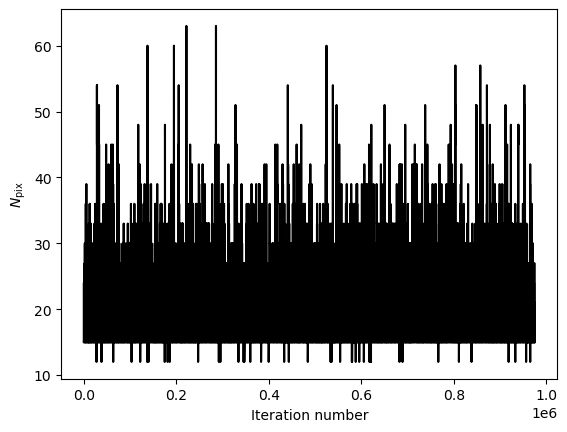

In [6]:
plt.plot(np.arange(len(lengths)), lengths, color='black')
plt.xlabel('Iteration number')
plt.ylabel(r'$N_\mathrm{pix}$')

### Now we sort the samples by mesh and count how many samples each mesh has

In [7]:
unique, unique_counts = np.unique(padded_meshes, return_counts=True, axis=0)

In [8]:
np.sort(unique_counts)[::-1][:10] # this shows the number of samples in each of the top 10 best meshes

array([605224,  27348,  26946,  26403,  25302,  24715,  24056,  22811,
        22590,   4064])

In [9]:
i_max, i_next_best = np.argsort(unique_counts)[::-1][0:2] # get indices of best mesh and next best mesh
preferred_mesh = unique[i_max][unique[i_max] > 0] # select preferred mesh and remove padding
next_best_mesh = unique[i_next_best][unique[i_next_best] > 0] # get next best mesh and remove padding

### The next cell gets Bayes factors between two meshes
#### I have it set to finding the Bayes factor between the best and next best mesh, but you can change this to whichever two meshes you want
#### We also get uncertainties on the Bayes factor through bootstrap resampling

In [10]:
padded_mesh_indices = np.repeat(np.argsort(unique_counts), repeats=np.sort(unique_counts))
N_bootstrap_samples = 100 # you can increase this if you like
bootstrap_samples = np.random.choice(padded_mesh_indices, size=(N_bootstrap_samples, padded_mesh_indices.shape[0]), replace=True)
# this next line is where you specify which two models you want to compare
bayes_factor_num_and_denom = np.sort(unique_counts)[::-1][0:2] # I'm indexing 0 and 1 to represent the best mesh (0) and the next best(1)
bayes_factor = bayes_factor_num_and_denom[0] / bayes_factor_num_and_denom[1]
# we'll get the 16th and 84th percentiles for the Bayes factor in the next line. change it if you like
# you'll also need to change i_max and i_next_best if you are comparing models other than the best and next best meshes
bayes_factor_percentiles = np.nanpercentile((bootstrap_samples == i_max).sum(1) / (bootstrap_samples == i_next_best).sum(1), [16,84])
bayes_factor_uncertainties = bayes_factor_percentiles - bayes_factor
bayes_factor, bayes_factor_uncertainties

(np.float64(22.130466578908877), array([-0.10474249,  0.14613679]))

### Next we get the posteriors for the best mesh and make a sky map

In [13]:
# first we select the samples corresponding to the best mesh from the chain
same_lengths = [sample for sample in samples if len(sample[0])==len(preferred_mesh)]
best_mesh_samples = [sample for sample in same_lengths if np.all(np.sort(sample[0]) == np.sort(preferred_mesh))]
# now we get the angular power density posteriors
posteriors = np.array([sample[1][np.argsort(sample[0])] for sample in best_mesh_samples])
posteriors.shape # (N_samples (without thinning), Npix)

(605224, 15)

#### Here's a diagnostic of histograms of 1d-marginalized posteriors of the angular power density per pixel
#### Each histogram respresents a seperate pixel

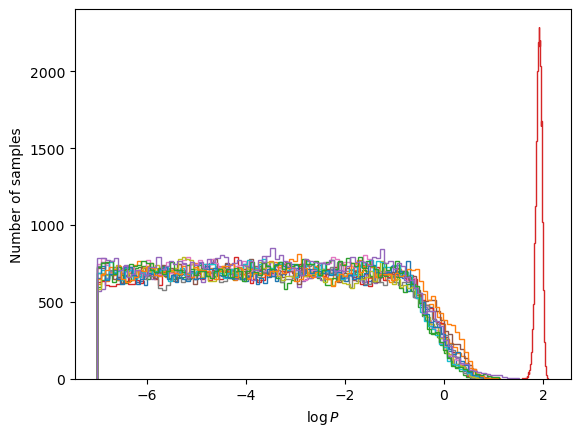

In [14]:
for i in range(posteriors.shape[1]): # loop over pixels
    plt.hist(posteriors[::10,i], bins=100, histtype='step') # thin the samples by e.g. 10 and plot histograms
plt.xlabel(r'$\log P$')
plt.ylabel('Number of samples')
plt.show()

### Now we move to the sky map, but we need a point estimate from the posteriors.
#### I'll use the mode of the 1d-marginalized posteriors

In [15]:
def mode(a, num_bins=100):
    counts, bins = np.histogram(a, bins=num_bins)
    return bins[np.argmax(counts)]

#### and here's the sky map

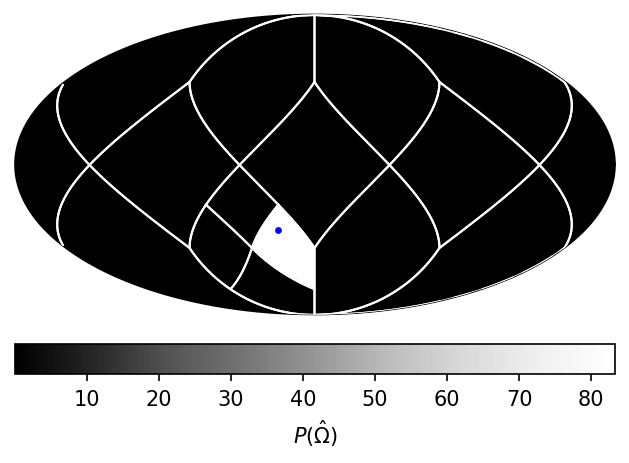

In [16]:
m = mhp.HealpixMap(uniq=preferred_mesh, data=10**np.array([mode(posteriors[:,ipix]) for ipix in range(posteriors.shape[1])]), density=True)
fig,ax = m.plot(ax_kw={'rot':180}, cbar=False, cmap='Greys_r')
m.plot_grid(ax=ax, linewidth=1, color='white')
plt.colorbar(fig, orientation='horizontal', pad=0.05, label=r'$P(\hat\Omega)$')

# plot points using the coordinate format (np.rad2deg(phi), 90 - np.rad2deg(theta))
# I have this next line representing a simulated CW, but you should of course remove this
# it's just showing how to scatter-plot points on the sky map
# you can also plot pulsar positions in the same way using np.rad2deg(psrs_phi), 90 - np.rad2deg(psrs_theta), etc.
ax.scatter(np.rad2deg(3.57), 90-np.rad2deg(2.13), transform=ax.get_transform('world'),
           color='blue', marker='.', s=20);